In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
data = pd.read_csv("heart.csv")

In [18]:
def median(values):

    values = list(values)
    values.sort()

    n = len(values)

    if n % 2 == 0:
        return (values[n // 2 - 1] + values[n // 2]) / 2

    else:
        return values[n // 2]

In [19]:
def quartiles(values):

    values = list(values)
    values.sort()

    n = len(values)

    middle = n // 2

    if n % 2 == 0:

        lower_half = values[:middle]
        upper_half = values[middle:]

    else:

        lower_half = values[:middle]
        upper_half = values[middle + 1:]

    q1 = median(lower_half)
    q3 = median(upper_half)

    return q1, q3

In [20]:
def find_outliers(values):

    values = list(values)

    q1, q3 = quartiles(values)

    iqr = q3 - q1

    lower_fence = q1 - (1.5 * iqr)

    upper_fence = q3 + (1.5 * iqr)

    outliers = []
    normal_values = []

    for value in values:

        if value < lower_fence or value > upper_fence:

            outliers.append(value)

        else:

            normal_values.append(value)

    return q1, q3, iqr, lower_fence, upper_fence, outliers, normal_values

In [21]:
values = data["chol"]

q1, q3, iqr, lower_fence, upper_fence, outliers, normal_values = find_outliers(values)

In [23]:
normal_values.sort()

minimum = normal_values[0]
maximum = normal_values[-1]

In [27]:
def get_median(values):

    values = list(values)
    values.sort()

    n = len(values)

    if n % 2 == 0:
        return (values[n // 2 - 1] + values[n // 2]) / 2

    else:
        return values[n // 2]

In [28]:
median_value = get_median(values)

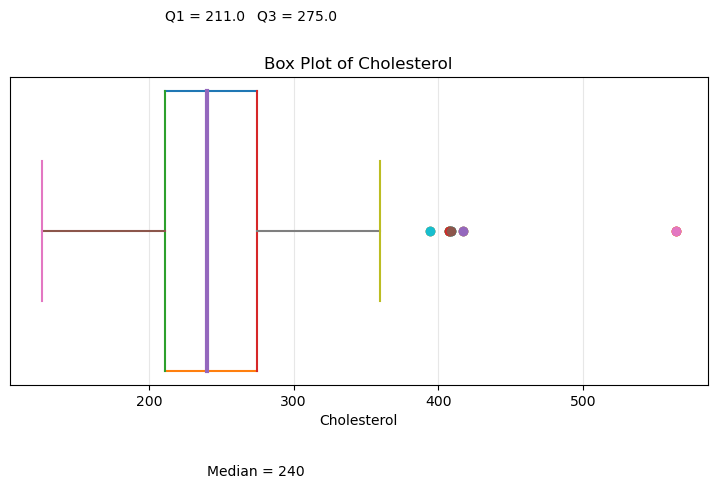

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))

# Draw box
plt.plot(
    [q1, q3],
    [1.2, 1.2]
)

plt.plot(
    [q1, q3],
    [0.8, 0.8]
)

plt.plot(
    [q1, q1],
    [0.8, 1.2]
)

plt.plot(
    [q3, q3],
    [0.8, 1.2]
)

# Median line
plt.plot(
    [median_value, median_value],
    [0.8, 1.2],
    linewidth=3
)

# Left whisker
plt.plot(
    [minimum, q1],
    [1, 1]
)

plt.plot(
    [minimum, minimum],
    [0.9, 1.1]
)

# Right whisker
plt.plot(
    [q3, maximum],
    [1, 1]
)

plt.plot(
    [maximum, maximum],
    [0.9, 1.1]
)

# Show outliers
for value in outliers:

    plt.scatter(
        value,
        1
    )

# Add labels
plt.text(
    q1,
    1.3,
    "Q1 = " + str(round(q1, 2))
)

plt.text(
    median_value,
    0.65,
    "Median = " + str(round(median_value, 2))
)

plt.text(
    q3,
    1.3,
    "Q3 = " + str(round(q3, 2))
)

plt.title("Box Plot of Cholesterol")

plt.xlabel("Cholesterol")

plt.yticks([])

plt.grid(alpha=0.3)

plt.show()